In [ ]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 4.5 MB/s eta 0:00:00


In [ ]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 5.1 MB/s eta 0:00:00


In [ ]:
import joblib
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

# Step 1: Load the complete dataset
df = pd.read_csv('/content/CDD (17544 ones,2924 zeros).csv')

X = df['sequence']
y = df['class']

# Step 2: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Find the maximum length of DNA sequences in the training data
max_sequence_len = X_train.apply(len).max()
print(f"Maximum sequence length in training data: {max_sequence_len}")

# Step 4: Preprocessing for CNN - One-Hot Encoding
def preprocess_data(data, max_len):
    mapping = {'A': 1, 'T': 2, 'C': 3, 'G': 4, 'N': 0}
    sequences = data.apply(lambda seq: [mapping.get(base, 0) for base in seq])
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')
    return padded_sequences

# Use the maximum sequence length found in Step 3 for padding
X_train_padded = preprocess_data(X_train, max_len=max_sequence_len)
X_test_padded = preprocess_data(X_test, max_len=max_sequence_len)

# Convert labels to categorical for CNN
y_train_onehot = to_categorical(y_train)
y_test_onehot = to_categorical(y_test)

# Step 5: Build and Train CNN Model
cnn_model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(max_sequence_len, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(np.expand_dims(X_train_padded, axis=-1), y_train, epochs=10, batch_size=32, validation_data=(np.expand_dims(X_test_padded, axis=-1), y_test))

cnn_test_pred_prob = cnn_model.predict(np.expand_dims(X_test_padded, axis=-1))
cnn_test_pred = (cnn_test_pred_prob > 0.5).astype(int)
cnn_accuracy = accuracy_score(y_test, cnn_test_pred)
print(f"CNN Test Accuracy: {cnn_accuracy * 100:.2f}%")

# Step 6: Preprocessing for XGBoost and Random Forest - Count Vectorizer
vectorizer = CountVectorizer(analyzer='char')
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Save the vectorizer for later use
joblib.dump(vectorizer, 'count_vectorizer.pkl')

# Step 7: Apply SMOTE for handling class imbalance on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_vect, y_train)

# Step 8: Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
rf_test_pred = rf_model.predict(X_test_vect)
rf_accuracy = accuracy_score(y_test, rf_test_pred)
print(f"Random Forest Test Accuracy: {rf_accuracy * 100:.2f}%")

# Step 9: Train XGBoost Model
dtrain_smote = xgb.DMatrix(X_train_smote, label=y_train_smote)
dtest = xgb.DMatrix(X_test_vect, label=y_test)
xgb_model = xgb.train(params={'objective': 'binary:logistic', 'eval_metric': 'logloss'}, dtrain=dtrain_smote, num_boost_round=100)
xgb_test_pred_prob = xgb_model.predict(dtest)
xgb_test_pred = (xgb_test_pred_prob > 0.5).astype(int)
xgb_accuracy = accuracy_score(y_test, xgb_test_pred)
print(f"XGBoost Test Accuracy: {xgb_accuracy * 100:.2f}%")

# Step 10: Calculate Weights for Stacking
average_accuracy = (cnn_accuracy + rf_accuracy + xgb_accuracy) / 3
cnn_weight = cnn_accuracy / average_accuracy
rf_weight = rf_accuracy / average_accuracy
xgb_weight = xgb_accuracy / average_accuracy

# Normalize weights
total_weight = cnn_weight + rf_weight + xgb_weight
cnn_weight /= total_weight
rf_weight /= total_weight
xgb_weight /= total_weight

print(f"Model Weights -> CNN: {cnn_weight:.3f}, Random Forest: {rf_weight:.3f}, XGBoost: {xgb_weight:.3f}")

# Step 11: Create Stacked Model with Weights as Initial Meta-Model Weights
stacked_predictions = np.column_stack((cnn_test_pred_prob, rf_test_pred, xgb_test_pred_prob))

def create_meta_model_with_weights():
    model = Sequential()
    model.add(Dense(3, input_dim=stacked_predictions.shape[1], activation='linear'))  # 3 inputs (CNN, RF, XGB)

    # Initialize the weights with accuracy ratios
    initial_weights = np.array([[cnn_weight, 0, 0], [0, rf_weight, 0], [0, 0, xgb_weight]])
    bias = np.array([0, 0, 0])  # Bias initialized to 0
    model.layers[0].set_weights([initial_weights, bias])

    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

meta_model = create_meta_model_with_weights()

# Step 12: Train the Meta-Model
meta_model.fit(stacked_predictions, y_test, epochs=10, batch_size=16, verbose=1)

# Step 13: Make Final Predictions with the Meta-Model
final_meta_pred_prob = meta_model.predict(stacked_predictions)
final_meta_pred = (final_meta_pred_prob > 0.5).astype(int)

# Step 14: Evaluate the Stacked Model
stacked_accuracy = accuracy_score(y_test, final_meta_pred)
print(f"Stacked Model Accuracy: {stacked_accuracy * 100:.2f}%")

# Step 15: Classification Report and Confusion Matrix
print("\nClassification Report:\n", classification_report(y_test, final_meta_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, final_meta_pred))


Maximum sequence length in training data: 1170


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8510 - loss: 0.4150 - val_accuracy: 0.9003 - val_loss: 0.2280
Epoch 2/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8976 - loss: 0.2277 - val_accuracy: 0.9038 - val_loss: 0.2105
Epoch 3/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9038 - loss: 0.2050 - val_accuracy: 0.9094 - val_loss: 0.2108
Epoch 4/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9052 - loss: 0.1965 - val_accuracy: 0.9116 - val_loss: 0.2203
Epoch 5/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9093 - loss: 0.1974 - val_accuracy: 0.9074 - val_loss: 0.2054
Epoch 6/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9241 - loss: 0.1796 - val_accuracy: 0.9099 - val_loss: 0.2105
Epoch 7/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9244 - loss: 0.1753 - val_accuracy: 0.9121 - val_loss: 0.2134
Epoch 8/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9248 - loss: 0.1710 - val_accuracy: 

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8589 - loss: 0.5021
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8548 - loss: 0.3029
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8624 - loss: 0.2569
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8701 - loss: 0.2492
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9146 - loss: 0.2272
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9219 - loss: 0.2323
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9248 - loss: 0.2187
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9307 - loss: 0.2031
Epoch 9/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9254 - loss: 0.2130
Epoch 10/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9302 - loss: 0.1972
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Stacked Model Accuracy: 92.72%

Classification Report:
               precision    recall  f1-score   support

In [ ]:
# Step 2: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Combine X_train and y_train, X_test and y_test into DataFrames
train_data = pd.DataFrame({'sequence': X_train, 'class': y_train})
test_data = pd.DataFrame({'sequence': X_test, 'class': y_test})

# Step 4: Save the train and test DataFrames as CSV files
train_data.to_csv('train_data.csv', index=False)
test_data.to_csv('test_data.csv', index=False)

print("Train and test data saved as 'train_data.csv' and 'test_data.csv'")

Train and test data saved as 'train_data.csv' and 'test_data.csv'


In [ ]:
import joblib
from tensorflow.keras.models import load_model

# Assuming cnn_model, rf_model, and xgb_model are your trained models

# Step 1: Save the CNN model as .h5 file
cnn_model.save('cnn_model.h5')
print("CNN model saved as 'cnn_model.h5'.")

# Step 2: Save the Random Forest model using joblib
joblib.dump(rf_model, 'random_forest_model.pkl')
print("Random Forest model saved as 'random_forest_model.pkl'.")

# Step 3: Save the XGBoost model as .json file
xgb_model.save_model('xgboost_model.json')
print("XGBoost model saved as 'xgboost_model.json'.")

# Step 4: Save the meta model for stacking
meta_model.save('stacked_model.h5')
print("Stacked model saved as 'stacked_model.h5'.")


CNN model saved as 'cnn_model.h5'.
Random Forest model saved as 'random_forest_model.pkl'.
XGBoost model saved as 'xgboost_model.json'.
Stacked model saved as 'stacked_model.h5'.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import joblib

# Assuming you already have your training data loaded in X_train
# For demonstration, let's say X_train contains DNA sequences as strings
X_train = train_data['sequence']  # Replace train_df with your actual training DataFrame
y_train = train_data['class']

# Step 1: Initialize and fit the CountVectorizer
vectorizer = CountVectorizer(analyzer='char', token_pattern=r'\w{1}', max_features=5000)
X_train_vect = vectorizer.fit_transform(X_train)

# Step 2: Save the CountVectorizer
joblib.dump(vectorizer, 'count_vectorizer.pkl')

print("CountVectorizer saved successfully.")

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:551: UserWarning: The parameter 'token_pattern' will not be used since 'analyzer' != 'word'
  warnings.warn(


CountVectorizer saved successfully.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model
import joblib
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder

# Load the test dataset
test_df = pd.read_csv('test_data.csv')
X_test = test_df['sequence']
y_test = test_df['class']

# Preprocess the test data
def preprocess_test_data(data, max_len):
    mapping = {'A': 1, 'T': 2, 'C': 3, 'G': 4, 'N': 0}
    sequences = data['sequence'].apply(lambda seq: [mapping.get(base, 0) for base in seq])
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')
    return padded_sequences

# Set max_sequence_len to the maximum length of sequences in training data
max_sequence_len = 1170
X_test_processed = preprocess_test_data(test_df, max_sequence_len)

# Load the saved models
cnn_model = load_model('cnn_model.h5')
rf_model = joblib.load('random_forest_model.pkl')
xgb_model = xgb.Booster()
xgb_model.load_model('xgboost_model.json')

# Load the vectorizer for Random Forest and XGBoost
vectorizer = joblib.load('count_vectorizer.pkl')  # Load the saved vectorizer

# Prepare data for predictions
X_test_vect = vectorizer.transform(X_test)  # Transform using the saved vectorizer

# Make predictions using each model
# CNN expects 3D input (samples, timesteps, features)
X_test_seq = np.expand_dims(X_test_processed, axis=-1)
cnn_pred_prob = cnn_model.predict(X_test_seq)
cnn_pred = (cnn_pred_prob > 0.5).astype(int)

# XGBoost predictions
dtest = xgb.DMatrix(X_test_vect)  # Create DMatrix for XGBoost
xgb_pred_prob = xgb_model.predict(dtest)
xgb_pred = (xgb_pred_prob > 0.5).astype(int)

# Random Forest predictions
rf_pred = rf_model.predict(X_test_vect)

# Stack predictions for the stacking model
stacked_predictions = np.column_stack((cnn_pred_prob, xgb_pred_prob, rf_pred))

# Load the stacking model (ensure it is saved before)
meta_model = load_model('stacked_model.h5')

# Make final predictions using the stacking model
final_pred_prob = meta_model.predict(stacked_predictions)
final_pred = (final_pred_prob > 0.5).astype(int)

# Function to calculate metrics
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return accuracy, precision, recall, f1

# Calculate metrics for CNN
cnn_metrics = calculate_metrics(y_test, cnn_pred)
print(f"CNN Model Metrics:\nAccuracy: {cnn_metrics[0]:.4f}, Precision: {cnn_metrics[1]:.4f}, Recall: {cnn_metrics[2]:.4f}, F1 Score: {cnn_metrics[3]:.4f}")

# Calculate metrics for XGBoost
xgb_metrics = calculate_metrics(y_test, xgb_pred)
print(f"XGBoost Model Metrics:\nAccuracy: {xgb_metrics[0]:.4f}, Precision: {xgb_metrics[1]:.4f}, Recall: {xgb_metrics[2]:.4f}, F1 Score: {xgb_metrics[3]:.4f}")

# Calculate metrics for Random Forest
rf_metrics = calculate_metrics(y_test, rf_pred)
print(f"Random Forest Model Metrics:\nAccuracy: {rf_metrics[0]:.4f}, Precision: {rf_metrics[1]:.4f}, Recall: {rf_metrics[2]:.4f}, F1 Score: {rf_metrics[3]:.4f}")

# Calculate metrics for Stacking Model
stacked_metrics = calculate_metrics(y_test, final_pred)
print(f"Stacked Model Metrics:\nAccuracy: {stacked_metrics[0]:.4f}, Precision: {stacked_metrics[1]:.4f}, Recall: {stacked_metrics[2]:.4f}, F1 Score: {stacked_metrics[3]:.4f}")

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CNN Model Metrics:
Accuracy: 0.9133, Precision: 0.9447, Recall: 0.9547, F1 Score: 0.9497
XGBoost Model Metrics:
Accuracy: 0.8945, Precision: 0.9630, Recall: 0.9119, F1 Score: 0.9368
Random Forest Model Metrics:
Accuracy: 0.9057, Precision: 0.9605, Recall: 0.9282, F1 Score: 0.9441
Stacked Model Metrics:
Accuracy: 0.9260, Precision: 0.9544, Recall: 0.9595, F1 Score: 0.9569


In [ ]:
import pandas as pd

# Assuming you have the metrics for each model calculated
metrics_data = {
    'Model': ['CNN', 'XGBoost', 'Random Forest', 'Stacked Ensemble'],
    'Accuracy': [cnn_metrics[0] * 100, xgb_metrics[0] * 100, rf_metrics[0] * 100, stacked_metrics[0] * 100],
    'Precision': [cnn_metrics[1]*100 , xgb_metrics[1] * 100, rf_metrics[1] * 100, stacked_metrics[1] * 100],
    'Recall': [cnn_metrics[2]*100 , xgb_metrics[2] * 100, rf_metrics[2] * 100, stacked_metrics[2] * 100],
    'F1 Score': [cnn_metrics[3]*100 , xgb_metrics[3] * 100, rf_metrics[3] * 100, stacked_metrics[3] * 100]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)

# Save the metrics DataFrame to a CSV file
print(metrics_df)
metrics_df.to_csv('model_metrics.csv', index=False)
print("Metrics saved to model_metrics.csv successfully.")

              Model   Accuracy  Precision     Recall   F1 Score
0               CNN  91.328774  94.472645  95.468795  94.968108
1           XGBoost  89.447973  96.298525  91.194072  93.676815
2     Random Forest  90.571568  96.048363  92.818467  94.405797
3  Stacked Ensemble  92.598925  95.436508  95.953263  95.694188
Metrics saved to model_metrics.csv successfully.


In [ ]:
import numpy as np

# Assuming X_train, X_test, y_train, and y_test are defined
# Save the arrays to .npy files
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

print("Data saved successfully as .npy files.")

Data saved successfully as .npy files.


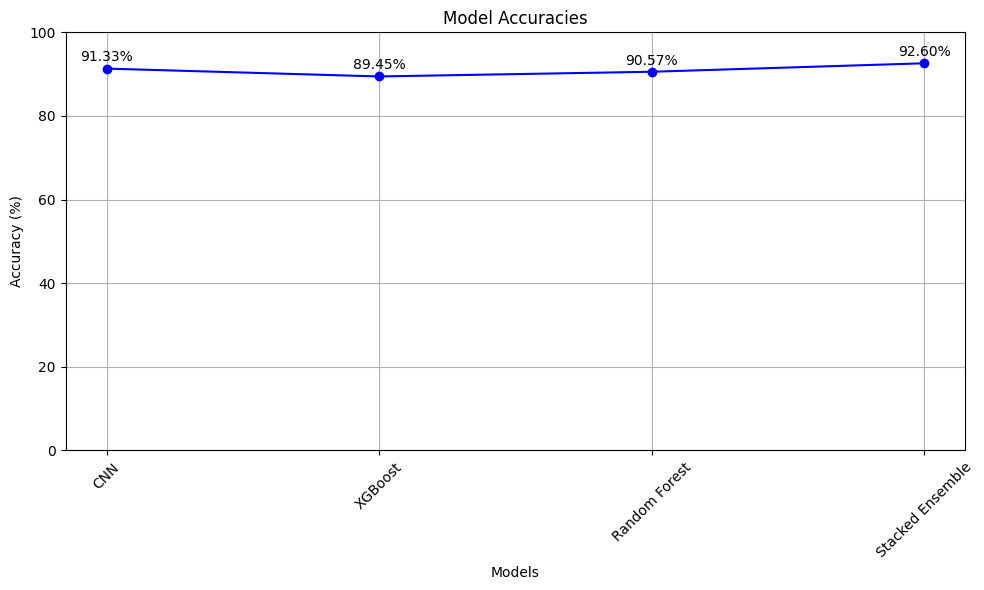

In [ ]:
import matplotlib.pyplot as plt

# Define model names and their corresponding accuracies
model_names = ['CNN', 'XGBoost', 'Random Forest', 'Stacked Ensemble']
accuracies = [cnn_metrics[0] * 100, xgb_metrics[0] * 100, rf_metrics[0] * 100, stacked_metrics[0] * 100]

# Plotting the accuracies
plt.figure(figsize=(10, 6))
plt.plot(model_names, accuracies, marker='o', linestyle='-', color='b')
plt.title('Model Accuracies')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.ylim([0, 100])  # Set the y-axis limit from 0 to 100
plt.grid()
plt.xticks(rotation=45)  # Rotate model names for better readability

# Annotate each point with the accuracy value
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', va='bottom')

plt.tight_layout()  # Adjust layout for better fit
plt.show()

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


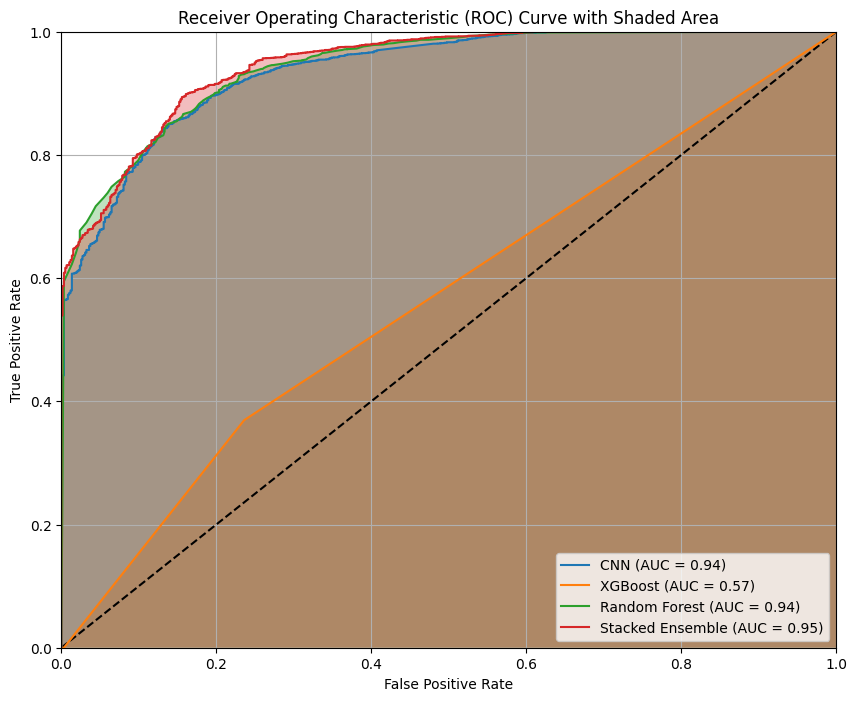

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Function to plot ROC Curve with shaded area
def plot_roc_curve_with_shading(y_test, preds, model_name):
    fpr, tpr, _ = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    # Shade the area under the curve
    plt.fill_between(fpr, tpr, alpha=0.3)

# Getting predicted probabilities
cnn_pred_prob = cnn_model.predict(X_test_seq).ravel()  # CNN predicted probabilities
xgb_pred_prob = bst.predict(dtest)  # XGBoost predicted probabilities
rf_pred_prob = rf_model.predict_proba(X_test_vect)[:, 1]  # Random Forest predicted probabilities
stacked_pred_prob = meta_model_with_weights.predict(stacked_predictions).ravel()  # Stacked predictions

# Plotting ROC curves
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (chance level)
plot_roc_curve_with_shading(y_test, cnn_pred_prob, 'CNN')
plot_roc_curve_with_shading(y_test, xgb_pred_prob, 'XGBoost')
plot_roc_curve_with_shading(y_test, rf_pred_prob, 'Random Forest')
plot_roc_curve_with_shading(y_test, stacked_pred_prob, 'Stacked Ensemble')

# Finalizing the plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid()
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.show()

In [ ]:
# Define the accuracies of each model (example values)
cnn_accuracy = cnn_metrics[0]
xgb_accuracy = xgb_metrics[0]
rf_accuracy = rf_metrics[0]

# Create a weights array (normalize the accuracies)
weights = np.array([cnn_accuracy, xgb_accuracy, rf_accuracy])
normalized_weights = weights / np.sum(weights)

# Calculate final_pred_prob_with_weights using weighted average
final_pred_prob_with_weights = (
    normalized_weights[0] * cnn_pred_prob.flatten() +
    normalized_weights[1] * xgb_pred_prob +
    normalized_weights[2] * rf_pred
)

# Apply threshold to get final predictions
final_pred_with_weights = (final_pred_prob_with_weights > 0.5).astype(int)

# Function to calculate metrics for the weighted predictions
weighted_metrics = calculate_metrics(y_test, final_pred_with_weights)
print(f"Weighted Stacked Model Metrics:\n"
      f"Accuracy: {weighted_metrics[0]:.4f}, "
      f"Precision: {weighted_metrics[1]:.4f}, "
      f"Recall: {weighted_metrics[2]:.4f}, "
      f"F1 Score: {weighted_metrics[3]:.4f}")

# Optionally, print the weighted probabilities for further analysis
print("Final predicted probabilities with weights:", final_pred_prob_with_weights)

Weighted Stacked Model Metrics:
Accuracy: 0.9055, Precision: 0.9605, Recall: 0.9279, F1 Score: 0.9439
Final predicted probabilities with weights: [0.7557573  0.8034097  0.8034097  ... 0.8034097  0.78497228 0.8034097 ]


In [ ]:
final_pred_with_weights = (final_pred_prob_with_weights > 0.5).astype(int)

In [ ]:
# Step 9: Evaluate the final stacked model with initialized weights
stacked_accuracy_with_weights = accuracy_score(y_test, final_pred_with_weights)
print(f"Stacked Model Accuracy with Weighted Initialization: {stacked_metrics[0] * 100:.2f}%")

# Print classification report and confusion matrix
print("\nClassification Report:\n", classification_report(y_test, final_pred_with_weights))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, final_pred_with_weights))

Stacked Model Accuracy with Weighted Initialization: 92.60%

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.77      0.70       585
           1       0.96      0.93      0.94      3509

    accuracy                           0.91      4094
   macro avg       0.80      0.85      0.82      4094
weighted avg       0.91      0.91      0.91      4094


Confusion Matrix:
 [[ 451  134]
 [ 253 3256]]


In [ ]:
# Calculate accuracies for weighting
cnn_accuracy = accuracy_score(y_test, cnn_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

# Normalize weights
total_accuracy = cnn_accuracy + xgb_accuracy + rf_accuracy
cnn_weight = cnn_accuracy / total_accuracy
xgb_weight = xgb_accuracy / total_accuracy
rf_weight = rf_accuracy / total_accuracy

# Calculate weighted predictions
weighted_preds = (cnn_weight * cnn_pred_prob.flatten() +
                  xgb_weight * xgb_pred_prob +
                  rf_weight * rf_pred)

# Convert to final binary predictions using threshold 0.5
final_pred_prob_with_weights = (weighted_preds > 0.5).astype(int)

# Stack predictions for the stacking model
stacked_predictions = np.column_stack((cnn_pred_prob.flatten(), xgb_pred_prob, rf_pred))

# Load the stacking model (ensure it is saved before)
meta_model = load_model('stacked_model.h5')

# Make final predictions using the stacking model
final_stacked_pred_prob = meta_model.predict(stacked_predictions)
final_stacked_pred = (final_stacked_pred_prob > 0.5).astype(int)

# Calculate metrics for Final Predictions with Weights
weighted_metrics = calculate_metrics(y_test, final_pred_prob_with_weights)
print(f"Final Predictions with Weights Metrics:\nAccuracy: {weighted_metrics[0]:.4f}, Precision: {weighted_metrics[1]:.4f}, Recall: {weighted_metrics[2]:.4f}, F1 Score: {weighted_metrics[3]:.4f}")

# Calculate metrics for Stacking Model
stacked_metrics = calculate_metrics(y_test, final_stacked_pred)
print(f"Stacked Model Metrics:\nAccuracy: {stacked_metrics[0]:.4f}, Precision: {stacked_metrics[1]:.4f}, Recall: {stacked_metrics[2]:.4f}, F1 Score: {stacked_metrics[3]:.4f}")

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Final Predictions with Weights Metrics:
Accuracy: 0.9055, Precision: 0.9605, Recall: 0.9279, F1 Score: 0.9439
Stacked Model Metrics:
Accuracy: 0.9240, Precision: 0.9484, Recall: 0.9638, F1 Score: 0.9560


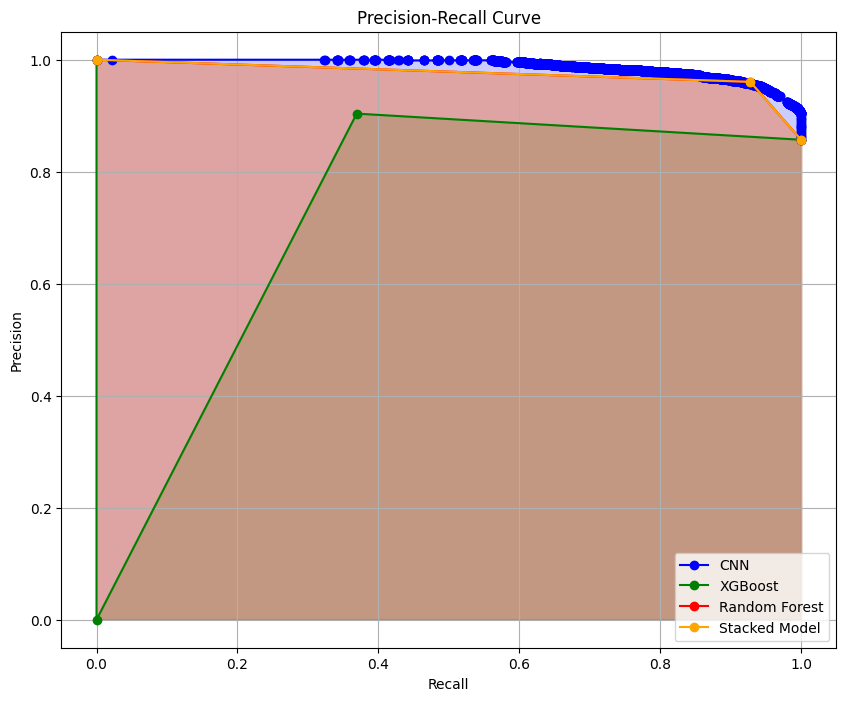

Average Precision Score (CNN): 0.99
Average Precision Score (XGBoost): 0.87
Average Precision Score (Random Forest): 0.95
Average Precision Score (Stacked Model): 0.95


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get predicted probabilities for each model
cnn_scores = cnn_pred_prob.flatten()
xgb_scores = xgb_pred_prob
rf_scores = rf_pred  # Ensure rf_pred are probabilities, if not, use rf_pred_prob instead
y_scores = final_pred_prob_with_weights  # Weighted predictions

# Compute precision-recall curve for each model
precision_cnn, recall_cnn, _ = precision_recall_curve(y_test, cnn_scores)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_scores)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_scores)
precision_stack, recall_stack, _ = precision_recall_curve(y_test, y_scores)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))
plt.plot(recall_cnn, precision_cnn, marker='o', color='blue', label='CNN')
plt.plot(recall_xgb, precision_xgb, marker='o', color='green', label='XGBoost')
plt.plot(recall_rf, precision_rf, marker='o', color='red', label='Random Forest')
plt.plot(recall_stack, precision_stack, marker='o', color='orange', label='Stacked Model')
plt.fill_between(recall_cnn, precision_cnn, alpha=0.2, color='blue')
plt.fill_between(recall_xgb, precision_xgb, alpha=0.2, color='green')
plt.fill_between(recall_rf, precision_rf, alpha=0.2, color='red')
plt.fill_between(recall_stack, precision_stack, alpha=0.2, color='orange')

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.legend()
plt.show()

# Print average precision scores for each model
avg_precision_cnn = average_precision_score(y_test, cnn_scores)
avg_precision_xgb = average_precision_score(y_test, xgb_scores)
avg_precision_rf = average_precision_score(y_test, rf_scores)
avg_precision_stack = average_precision_score(y_test, y_scores)

print(f'Average Precision Score (CNN): {avg_precision_cnn:.2f}')
print(f'Average Precision Score (XGBoost): {avg_precision_xgb:.2f}')
print(f'Average Precision Score (Random Forest): {avg_precision_rf:.2f}')
print(f'Average Precision Score (Stacked Model): {avg_precision_stack:.2f}')

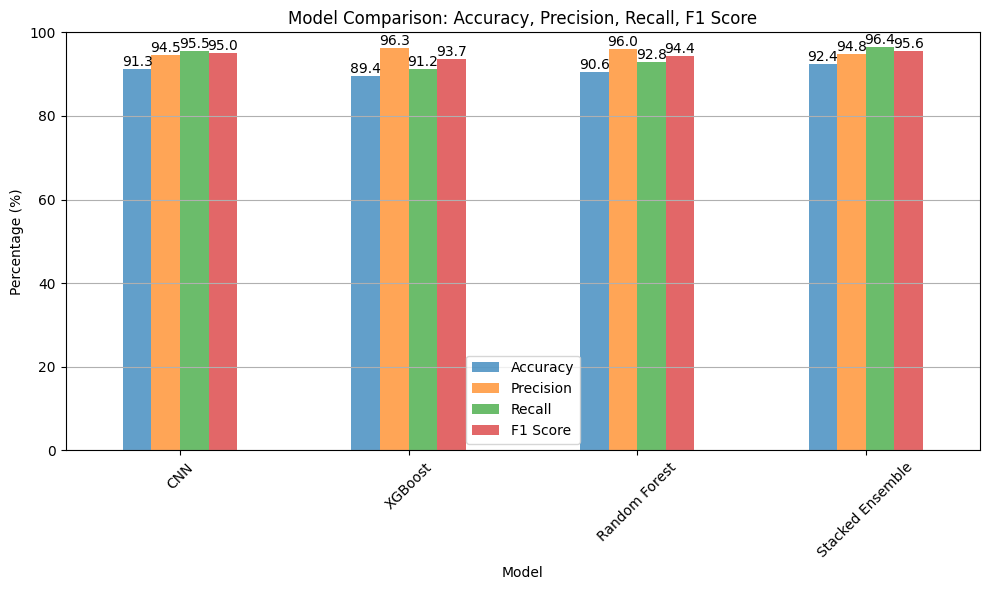

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define metrics for each model
metrics_data = {
    'Model': ['CNN', 'XGBoost', 'Random Forest', 'Stacked Ensemble'],
    'Accuracy': [cnn_metrics[0] * 100, xgb_metrics[0] * 100, rf_metrics[0] * 100, stacked_metrics[0] * 100],
    'Precision': [cnn_metrics[1] * 100, xgb_metrics[1] * 100, rf_metrics[1] * 100, stacked_metrics[1] * 100],
    'Recall': [cnn_metrics[2] * 100, xgb_metrics[2] * 100, rf_metrics[2] * 100, stacked_metrics[2] * 100],
    'F1 Score': [cnn_metrics[3] * 100, xgb_metrics[3] * 100, rf_metrics[3] * 100, stacked_metrics[3] * 100]
}

metrics_df = pd.DataFrame(metrics_data)

# Plotting
ax = metrics_df.set_index('Model').plot(kind='bar', figsize=(10, 6), alpha=0.7)

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge')

plt.title('Model Comparison: Accuracy, Precision, Recall, F1 Score')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

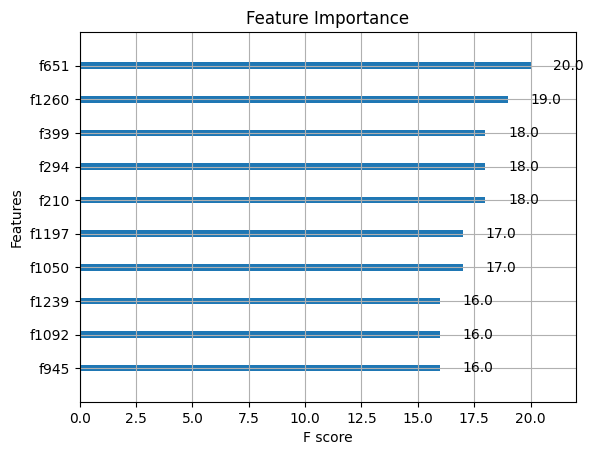

In [ ]:
# Plot feature importance for XGBoost
xgb.plot_importance(bst, title='Feature Importance', xlabel='F score', ylabel='Features', importance_type='weight', max_num_features=10)
plt.show()

CNN Weight: 0.3366, XGBoost Weight: 0.3296, Random Forest Weight: 0.3338


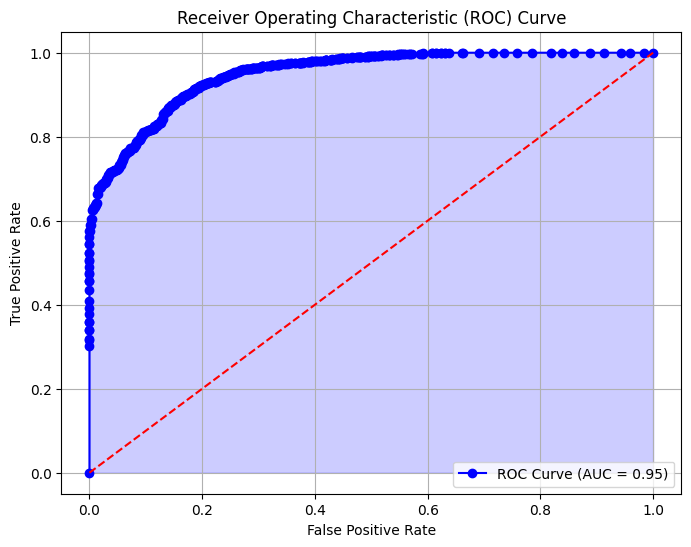

Average Precision Score: 0.99


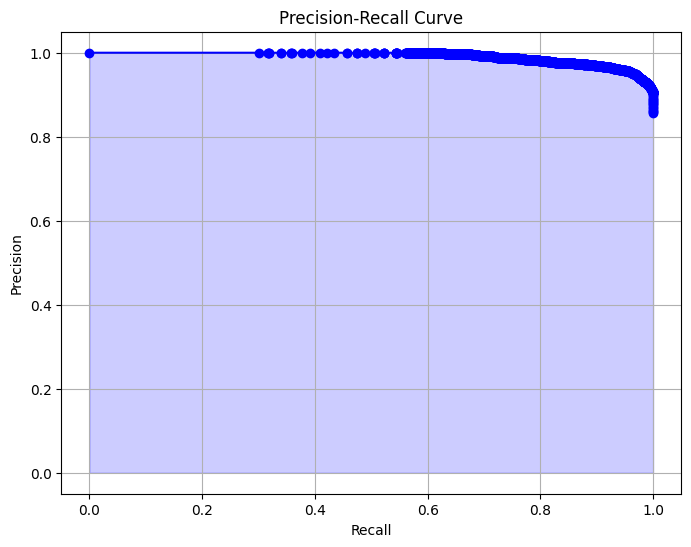

In [ ]:
# Calculate accuracies for weighting
cnn_accuracy = cnn_metrics[0]
xgb_accuracy = xgb_metrics[0]
rf_accuracy = rf_metrics[0]

# Normalize weights
total_accuracy = cnn_accuracy + xgb_accuracy + rf_accuracy
cnn_weight = cnn_accuracy / total_accuracy
xgb_weight = xgb_accuracy / total_accuracy
rf_weight = rf_accuracy / total_accuracy

# Calculate weighted predictions
weighted_preds = (cnn_weight * cnn_pred_prob.flatten() +
                  xgb_weight * xgb_pred_prob +
                  rf_weight * rf_pred_prob)

# Convert to final binary predictions using threshold 0.5
final_pred_with_weights = (weighted_preds > 0.5).astype(int)

# Optional: Print out the weights and the final predictions
print(f"CNN Weight: {cnn_weight:.4f}, XGBoost Weight: {xgb_weight:.4f}, Random Forest Weight: {rf_weight:.4f}")

y_scores = weighted_preds

# Calculate ROC curve and AUC for the Stacked Model
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_value = roc_auc_score(y_test, y_scores)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='o', color='b', label='ROC Curve (AUC = {:.2f})'.format(auc_value))
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

# Print average precision score
avg_precision = average_precision_score(y_test, y_scores)
print(f'Average Precision Score: {avg_precision:.2f}')

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='o', color='b')
plt.fill_between(recall, precision, alpha=0.2, color='blue')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()

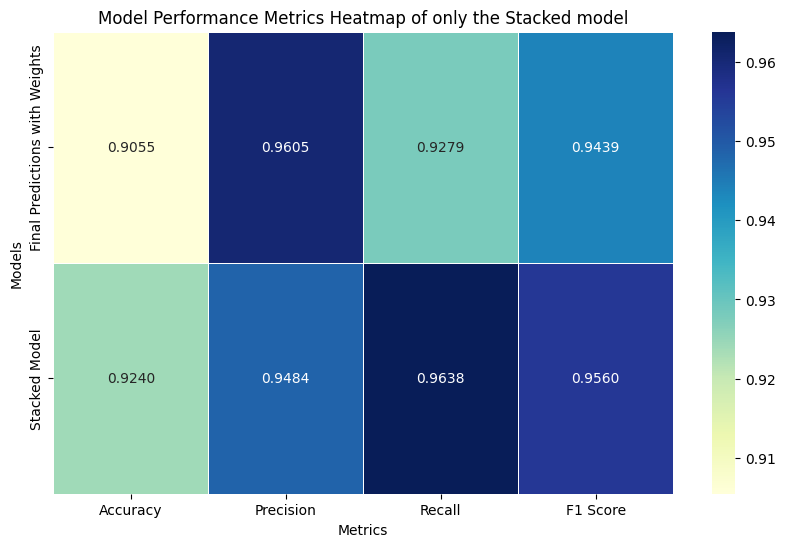

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics for each model
metrics_data = {
    'Model': ['Final Predictions with Weights', 'Stacked Model'],
    'Accuracy': [weighted_metrics[0], stacked_metrics[0]],
    'Precision': [weighted_metrics[1], stacked_metrics[1]],
    'Recall': [weighted_metrics[2], stacked_metrics[2]],
    'F1 Score': [weighted_metrics[3], stacked_metrics[3]]
}

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Set the Model as the index
metrics_df.set_index('Model', inplace=True)

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, cmap='YlGnBu', fmt=".4f", linewidths=.5)
plt.title('Model Performance Metrics Heatmap of only the Stacked model')
plt.ylabel('Models')
plt.xlabel('Metrics')
plt.show()

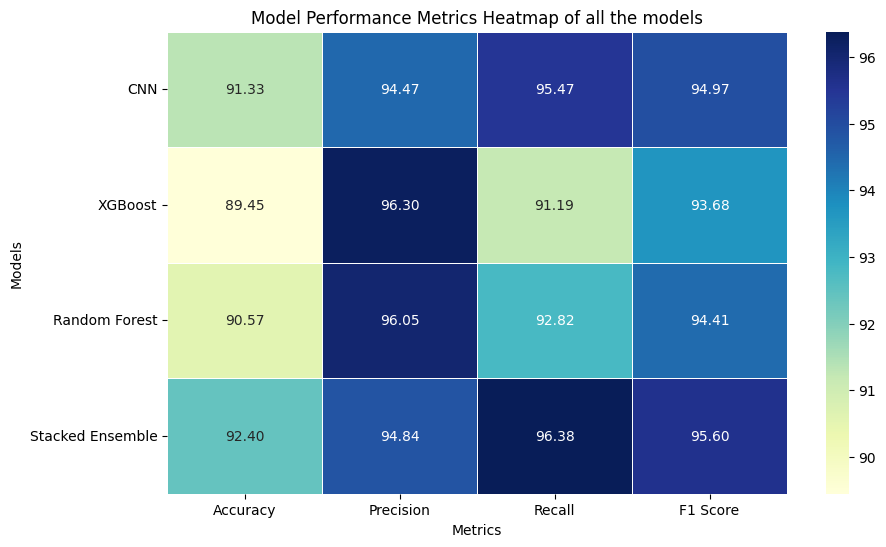

In [ ]:
metrics_data = {
    'Model': ['CNN', 'XGBoost', 'Random Forest', 'Stacked Ensemble'],
    'Accuracy': [cnn_metrics[0] * 100, xgb_metrics[0] * 100, rf_metrics[0] * 100, stacked_metrics[0] * 100],
    'Precision': [cnn_metrics[1]*100 , xgb_metrics[1] * 100, rf_metrics[1] * 100, stacked_metrics[1] * 100],
    'Recall': [cnn_metrics[2]*100 , xgb_metrics[2] * 100, rf_metrics[2] * 100, stacked_metrics[2] * 100],
    'F1 Score': [cnn_metrics[3]*100 , xgb_metrics[3] * 100, rf_metrics[3] * 100, stacked_metrics[3] * 100]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)
metrics_df.set_index('Model', inplace=True)

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Model Performance Metrics Heatmap of all the models')
plt.ylabel('Models')
plt.xlabel('Metrics')
plt.show()

In [ ]:
# Create a DataFrame for final predictions, including the DNA sequences and true labels
final_predictions_df = pd.DataFrame({
    'DNA Sequence': X_test.values,  # Add the DNA sequences from the test set
    'True Class': y_test,
    'CNN Prediction': cnn_test_pred.flatten(),
    'Random Forest Prediction': rf_test_pred,
    'XGBoost Prediction': xgb_test_pred,
    'Stacked Prediction': final_meta_pred.flatten(),
    'CNN Pred Prob Class 1': cnn_test_pred_prob.flatten(),  # Probability for class 1
    'XGBoost Pred Prob Class 1': xgb_test_pred_prob,        # Probability for class 1
    'Random Forest Pred Prob Class 0': rf_test_pred_prob[:, 0],  # Probability for class 0
    'Random Forest Pred Prob Class 1': rf_test_pred_prob[:, 1]   # Probability for class 1
})

# Save the final predictions DataFrame to a CSV file
final_predictions_df.to_csv('final_predictions_with_sequences.csv', index=False)

# Display the final predictions DataFrame
print(final_predictions_df.head())

                                        DNA Sequence  True Class  \
0  TCTTTCCTTTCATTTCACTTCACTTCACTACACTACACTACACTAC...           1   
1  CGTGCTGTGCTGTGCTGCGCTGCGCTGCGCTGCGCCGCGCCACGCC...           1   
2  CGTGCTGTGCTGTGCTGCGCTGCGCTGCGCTGCGCCGCGCCACGCC...           1   
3  GGTTGGGTTGGATTGGAGTGGAGCGGAGCTGAGCTTAGCTTCGCTT...           1   
4  CGTGCTGTGCTGTGCTGCGCTGCGCTGCGCTGCGCCGCGCCACGCC...           1   

   CNN Prediction  Random Forest Prediction  XGBoost Prediction  \
0               1                         1                   1   
1               1                         1                   1   
2               1                         1                   1   
3               1                         1                   1   
4               1                         1                   1   

   Stacked Prediction  CNN Pred Prob Class 1  XGBoost Pred Prob Class 1  \
0                   1               0.913154                   0.944559   
1                   1               0.